## Prophet Implementation ':\)'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import logging

from tqdm.notebook import tqdm
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

In [2]:
# ---------------------------------------------------------
# 1. Load Parquet & Replicate Teammate's Sample
# ---------------------------------------------------------
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet', engine='pyarrow')

# Use the EXACT same seed and sample as the Linear Regression notebook
random.seed(42)
all_clients = sorted(df_long['ClientID'].unique().tolist())
sampled_clients = random.sample(all_clients, 30)

# ---------------------------------------------------------
# DEBUG MODE: set to True to run on 3 clients only (~2 min vs ~15 min)
# One representative per problematic cluster for fast iteration
# ---------------------------------------------------------
DEBUG_MODE = False
debug_clients = ['MT_347', 'MT_328', 'MT_013']  # Clusters 0, 1, 3 

if DEBUG_MODE:
    sampled_clients = debug_clients
    print(f"DEBUG MODE: running on {len(sampled_clients)} clients: {sampled_clients}")
else:
    print(f"Starting Prophet evaluation for {len(sampled_clients)} clients. This may take a few minutes...")

Loading processed data...
Starting Prophet evaluation for 30 clients. This may take a few minutes...


In [3]:
# ---------------------------------------------------------
# 2. Initialize Metric Trackers
# ---------------------------------------------------------
all_wmapes = []
all_mapes  = []
all_maes   = []
all_mses   = []
all_rmses  = []

In [4]:
# ---------------------------------------------------------
# 3. The Grand Prophet Loop
# ---------------------------------------------------------
FORECAST_HORIZON = 96
all_predictions  = {}

for client_id in tqdm(sampled_clients, desc="Training Prophet Models"):
    client_df = df_long[df_long['ClientID'] == client_id].copy()
    client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
    client_df = client_df.sort_values('ds').reset_index(drop=True)

    train_df = client_df.iloc[:-FORECAST_HORIZON]
    test_df  = client_df.iloc[-FORECAST_HORIZON:]

    m = Prophet(changepoint_prior_scale=0.15, daily_seasonality=False)
    m.add_country_holidays(country_name='PT')
    m.add_regressor('Temp_National_Avg')
    m.add_regressor('Lag_15min')
    m.add_regressor('Lag_24h')
    m.add_regressor('Rolling_Mean_4h')
    m.fit(train_df)

    future_steps = test_df[['ds', 'Temp_National_Avg']].copy().reset_index(drop=True)
    history_y    = list(train_df['y'].values)
    clean_predictions = []

    for step in range(FORECAST_HORIZON):
        current_step = future_steps.iloc[[step]].copy()
        current_step['Lag_15min']       = history_y[-1]
        current_step['Lag_24h']         = history_y[-96]
        current_step['Rolling_Mean_4h'] = np.mean(history_y[-16:])

        yhat = m.predict(current_step)['yhat'].values[0]
        clean_predictions.append(yhat)
        history_y.append(yhat)

    y_true = test_df['y'].values
    y_pred = np.maximum(np.array(clean_predictions), 0)

    sum_actual = np.sum(y_true)
    wmape = np.sum(np.abs(y_true - y_pred)) / sum_actual if sum_actual > 0 else 0.0
    all_wmapes.append(wmape)

    nz   = y_true > 0.1
    mape = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) if nz.sum() > 0 else 0.0
    all_mapes.append(mape)

    all_maes.append(mean_absolute_error(y_true, y_pred))
    all_mses.append(mean_squared_error(y_true, y_pred))
    all_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    all_predictions[client_id] = {'test_df': test_df, 'y_pred': y_pred}

Training Prophet Models:   0%|          | 0/30 [00:00<?, ?it/s]

22:34:15 - cmdstanpy - INFO - Chain [1] start processing
22:34:42 - cmdstanpy - INFO - Chain [1] done processing
22:34:50 - cmdstanpy - INFO - Chain [1] start processing
22:34:54 - cmdstanpy - INFO - Chain [1] done processing
22:35:01 - cmdstanpy - INFO - Chain [1] start processing
22:35:05 - cmdstanpy - INFO - Chain [1] done processing
22:35:12 - cmdstanpy - INFO - Chain [1] start processing
22:35:18 - cmdstanpy - INFO - Chain [1] done processing
22:35:25 - cmdstanpy - INFO - Chain [1] start processing
22:35:35 - cmdstanpy - INFO - Chain [1] done processing
22:35:39 - cmdstanpy - INFO - Chain [1] start processing
22:35:40 - cmdstanpy - INFO - Chain [1] done processing
22:35:47 - cmdstanpy - INFO - Chain [1] start processing
22:35:55 - cmdstanpy - INFO - Chain [1] done processing
22:36:02 - cmdstanpy - INFO - Chain [1] start processing
22:36:08 - cmdstanpy - INFO - Chain [1] done processing
22:36:15 - cmdstanpy - INFO - Chain [1] start processing
22:36:18 - cmdstanpy - INFO - Chain [1]

In [5]:
print("--- 30-CLIENT PROPHET BENCHMARK RESULTS ---")
print(f"Average MAPE:  {np.mean(all_mapes):.2%}")
print(f"Average WMAPE: {np.mean(all_wmapes):.2%}")
print(f"Average MAE:   {np.mean(all_maes):.2f} kW")
print(f"Average MSE:   {np.mean(all_mses):.2f}")
print(f"Average RMSE:  {np.mean(all_rmses):.2f} kW")

--- 30-CLIENT PROPHET BENCHMARK RESULTS ---
Average MAPE:  649.00%
Average WMAPE: 40.34%
Average MAE:   35.68 kW
Average MSE:   7205.04
Average RMSE:  50.45 kW


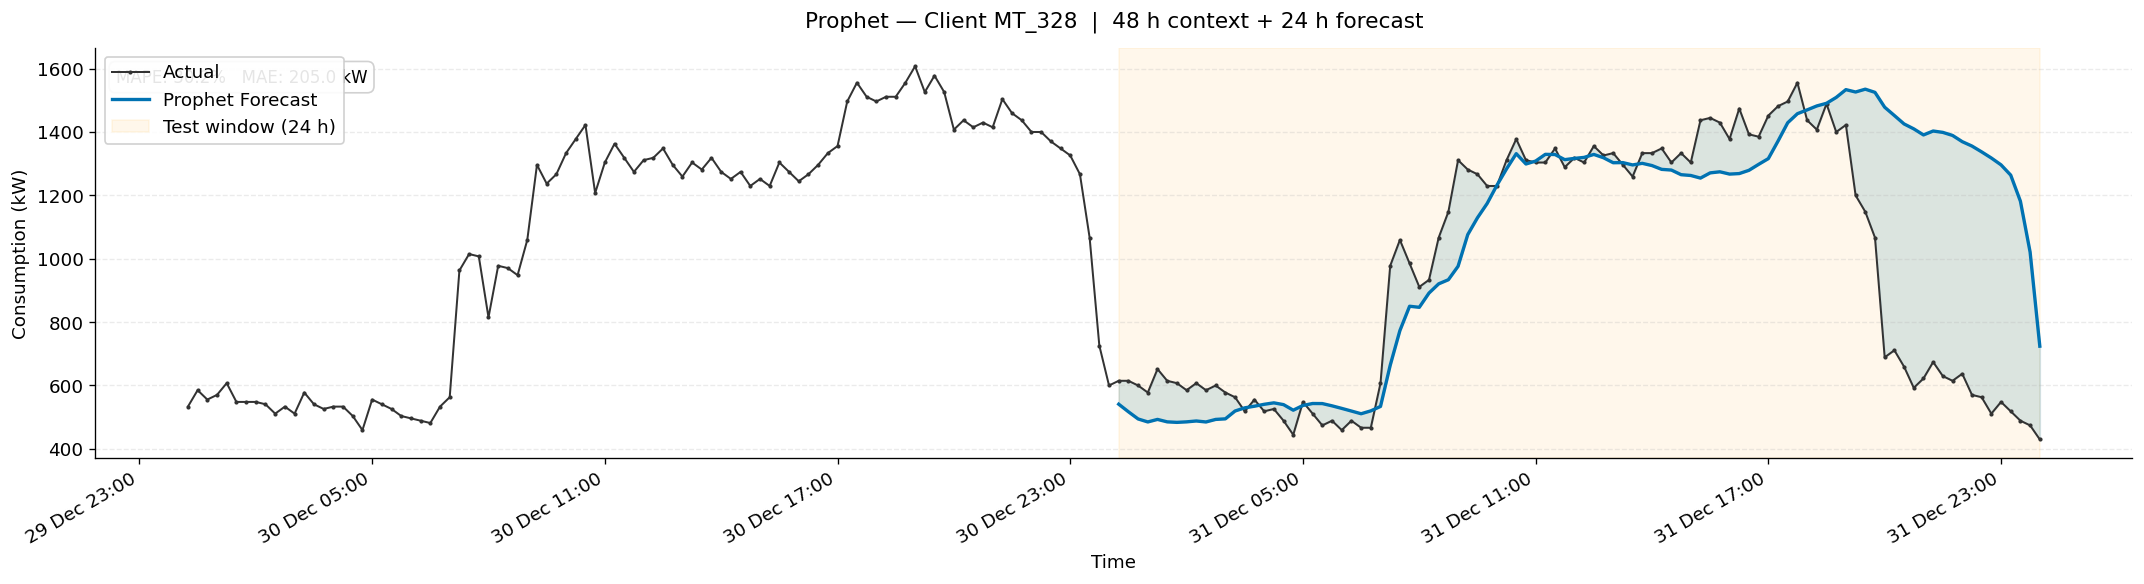

In [6]:
# ---------------------------------------------------------
# 4. Visualization — First client forecast (48 h context + 24 h forecast)
# ---------------------------------------------------------
first_client = sampled_clients[0]
data = all_predictions[first_client]

zoom_idx = -192  # 48 h of context at 15-min resolution

client_df = df_long[df_long['ClientID'] == first_client].copy()
client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
client_df = client_df.sort_values('ds').reset_index(drop=True)

first_idx = sampled_clients.index(first_client)
mae_val   = all_maes[first_idx]
mape_val  = all_mapes[first_idx]

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(client_df['ds'].iloc[zoom_idx:], client_df['y'].iloc[zoom_idx:],
        label='Actual', color='#333333', linewidth=1.2, marker='.', markersize=3)
ax.plot(data['test_df']['ds'], data['y_pred'],
        label='Prophet Forecast', color='#0072B2', linewidth=2)
ax.fill_between(data['test_df']['ds'],
                data['test_df']['y'].values, data['y_pred'],
                alpha=0.15, color='#0072B2')
ax.axvspan(data['test_df']['ds'].iloc[0], data['test_df']['ds'].iloc[-1],
           color='#FFA500', alpha=0.08, label='Test window (24 h)')

ax.text(0.01, 0.95, f"MAPE: {mape_val:.1%}   MAE: {mae_val:.1f} kW",
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9))

ax.set_title(f"Prophet — Client {first_client}  |  48 h context + 24 h forecast", pad=12)
ax.set_xlabel('Time')
ax.set_ylabel('Consumption (kW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.25, linestyle='--')
ax.xaxis.grid(False)
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

In [7]:
# ---------------------------------------------------------
# 5. Performance Breakdown by Cluster
# ---------------------------------------------------------
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')

results_df = pd.DataFrame({
    'ClientID': sampled_clients,
    'MAE':   all_maes,
    'RMSE':  all_rmses,
    'MAPE':  all_mapes,
    'WMAPE': all_wmapes
})

results_df = results_df.merge(cluster_map, on='ClientID')

print("--- PROPHET PERFORMANCE BY CLUSTER ---\n")
summary = results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    MAE=('MAE', 'mean'),
    RMSE=('RMSE', 'mean'),
    MAPE=('MAPE', 'mean'),
    WMAPE=('WMAPE', 'mean')
).round(3)
# Format MAPE and WMAPE as percentages for readability
summary['MAPE']  = summary['MAPE'].map('{:.1%}'.format)
summary['WMAPE'] = summary['WMAPE'].map('{:.1%}'.format)
print(summary.to_string())

--- PROPHET PERFORMANCE BY CLUSTER ---

         n_clients     MAE    RMSE     MAPE  WMAPE
Cluster                                           
0                2  61.576  84.845    12.5%   7.9%
1                7  55.885  90.083    32.0%  23.6%
2                6  24.042  31.481    16.7%  16.7%
3                6  10.318  12.237    24.3%  23.8%
4                9  38.880  50.094  2108.3%  87.4%


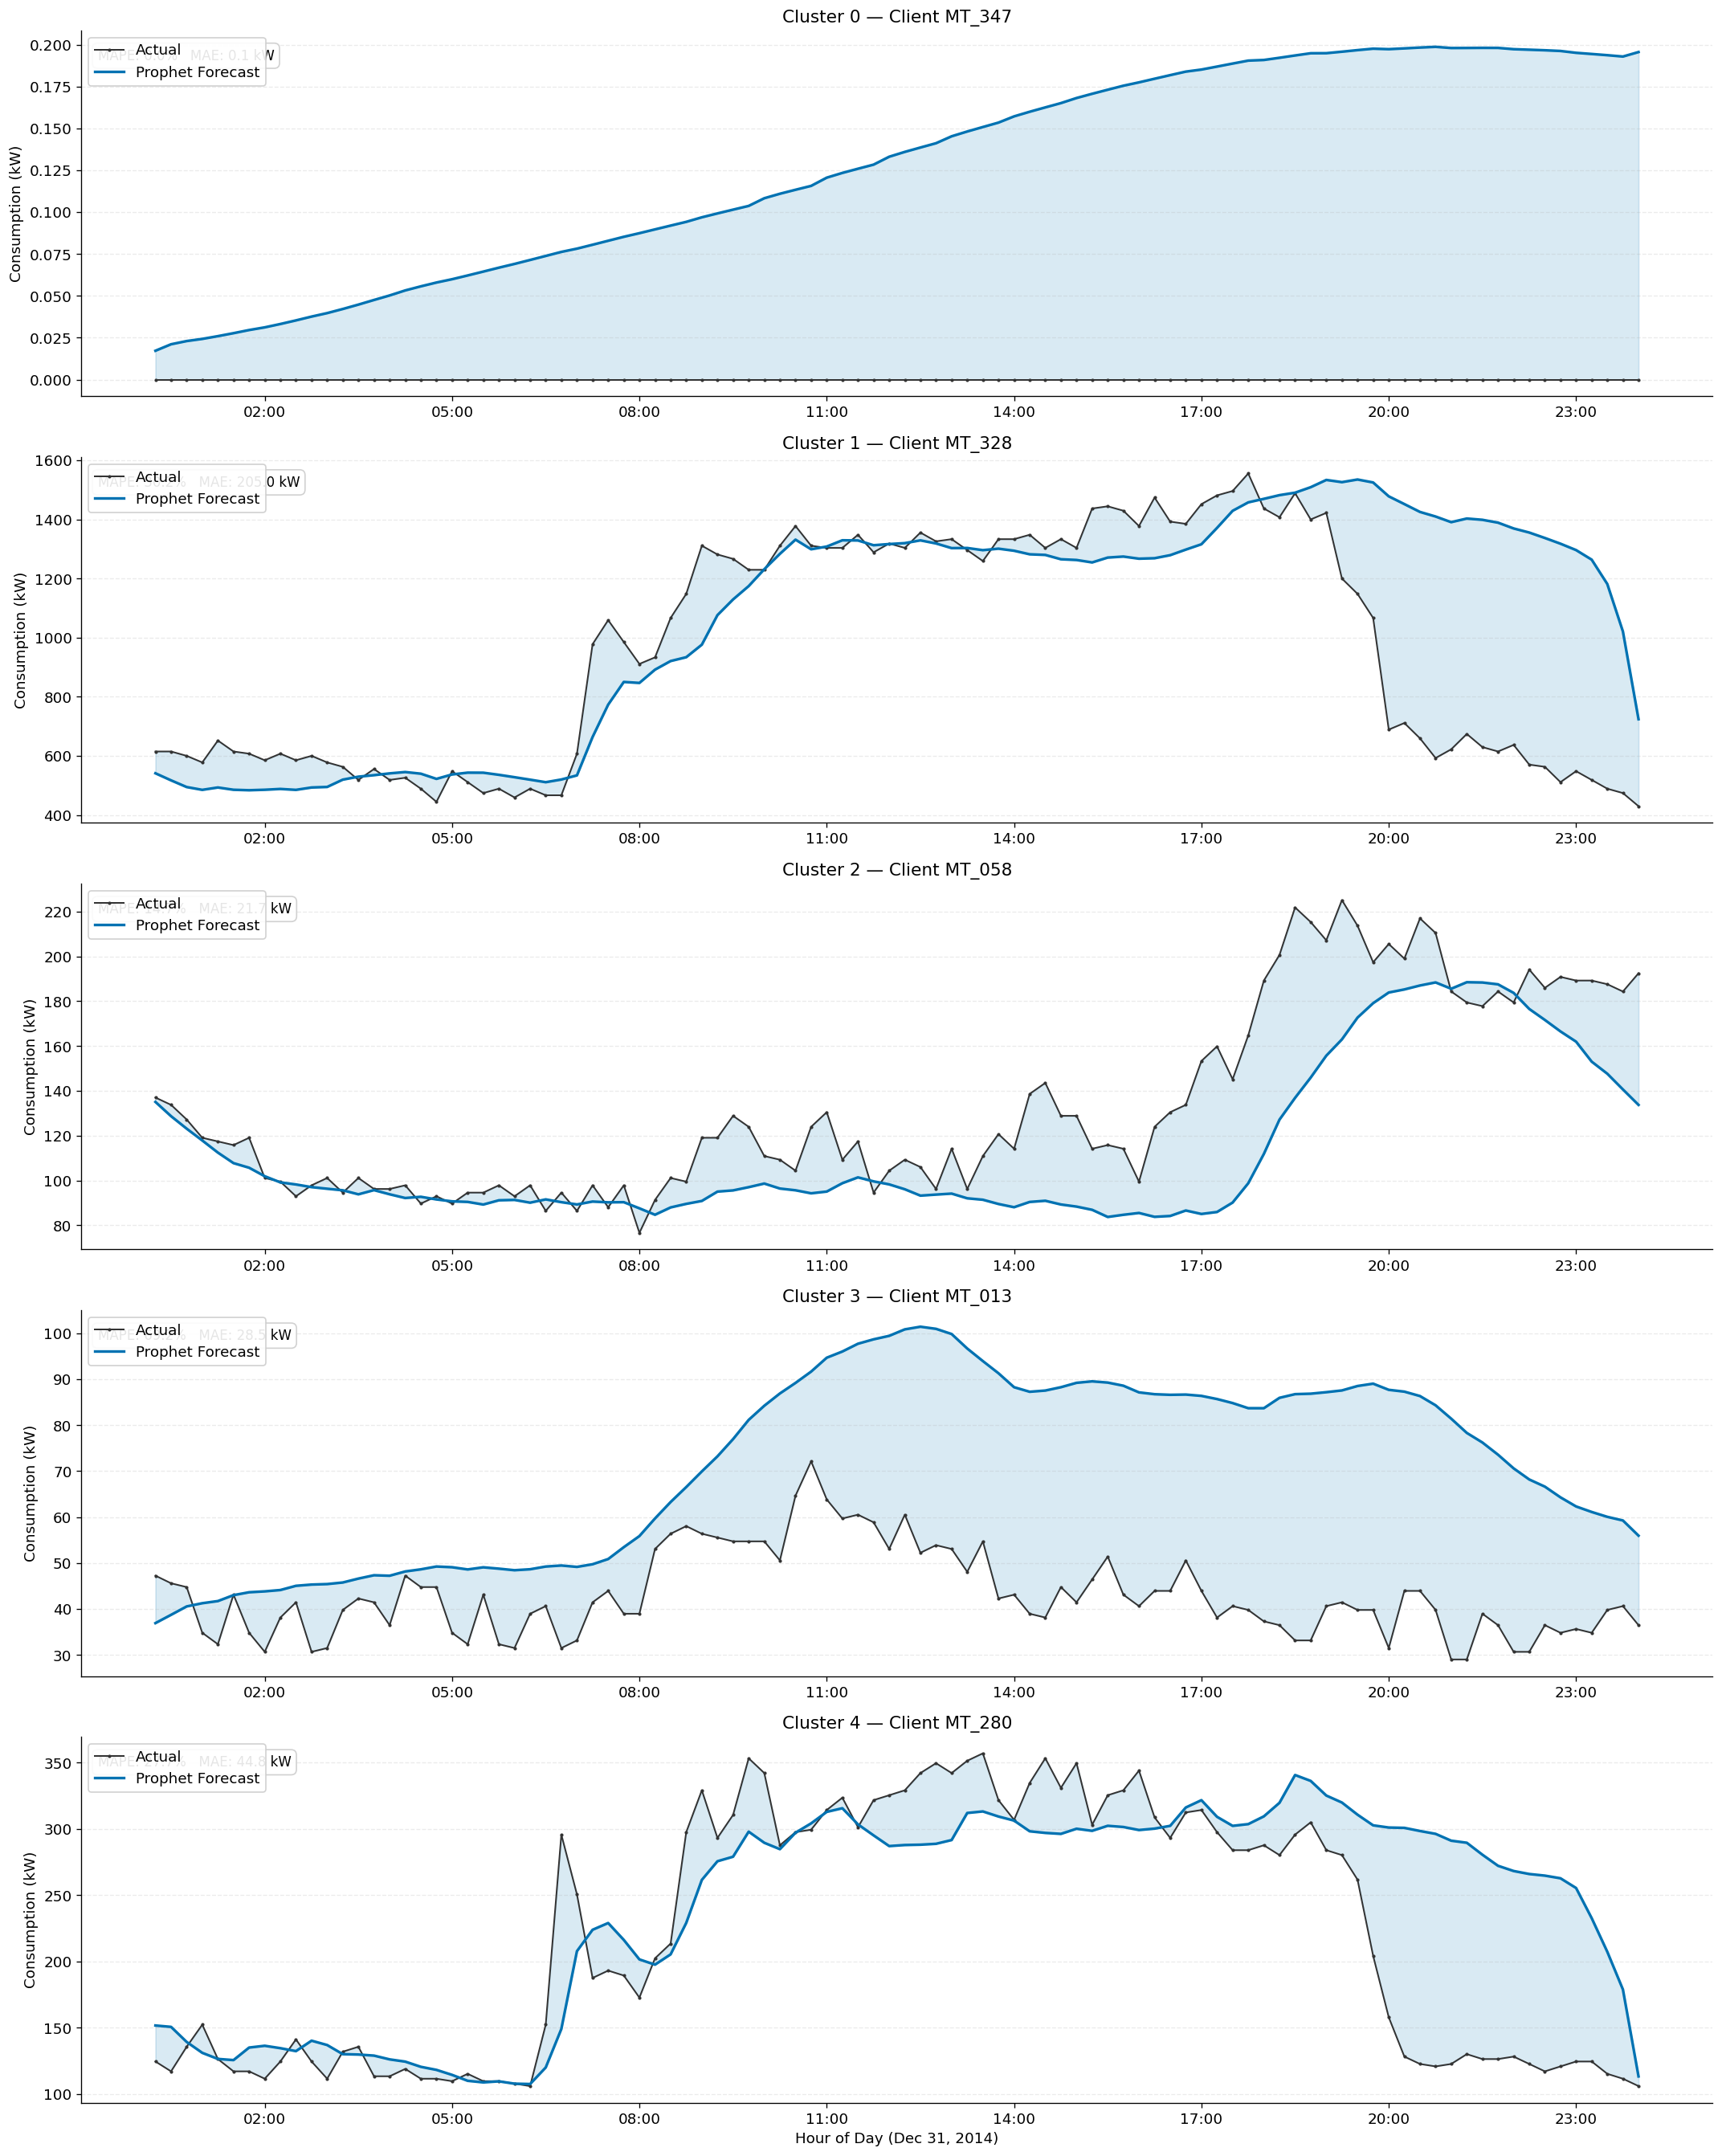

In [8]:
# ---------------------------------------------------------
# 6. Visualization: One Client per Cluster
# ---------------------------------------------------------
cluster_representatives = (
    results_df.groupby('Cluster')['ClientID'].first().to_dict()
)

fig, axes = plt.subplots(len(cluster_representatives), 1,
                         figsize=(18, 4.5 * len(cluster_representatives)))
if len(cluster_representatives) == 1:
    axes = [axes]

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx]
    data = all_predictions[client_id]

    x      = data['test_df']['ds'].values
    y_true = data['test_df']['y'].values
    y_pred = data['y_pred']

    row      = results_df[results_df['ClientID'] == client_id].iloc[0]
    mae_val  = row['MAE']
    mape_val = row['MAPE']

    ax.plot(x, y_true, label='Actual', color='#333333', linewidth=1.2,
            marker='.', markersize=3)
    ax.plot(x, y_pred, label='Prophet Forecast', color='#0072B2', linewidth=2)
    ax.fill_between(x, y_true, y_pred, alpha=0.15, color='#0072B2')

    ax.text(0.01, 0.95, f"MAPE: {mape_val:.1%}   MAE: {mae_val:.1f} kW",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    ax.set_title(f"Cluster {cluster_id} — Client {client_id}")
    ax.set_ylabel('Consumption (kW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, alpha=0.25, linestyle='--')
    ax.xaxis.grid(False)
    ax.legend(loc='upper left', framealpha=0.9)

axes[-1].set_xlabel('Hour of Day (Dec 31, 2014)')
plt.tight_layout()
plt.show()